In [1]:
import pandas as pd

data=pd.read_csv("dataset.csv")
data.head

<bound method NDFrame.head of               Date Location  MinTemp  MaxTemp  Rainfall  Evaporation  \
0       2008-12-01   Albury     13.4     22.9       0.6          NaN   
1       2008-12-02   Albury      7.4     25.1       0.0          NaN   
2       2008-12-03   Albury     12.9     25.7       0.0          NaN   
3       2008-12-04   Albury      9.2     28.0       0.0          NaN   
4       2008-12-05   Albury     17.5     32.3       1.0          NaN   
...            ...      ...      ...      ...       ...          ...   
145455  2017-06-21    Uluru      2.8     23.4       0.0          NaN   
145456  2017-06-22    Uluru      3.6     25.3       0.0          NaN   
145457  2017-06-23    Uluru      5.4     26.9       0.0          NaN   
145458  2017-06-24    Uluru      7.8     27.0       0.0          NaN   
145459  2017-06-25    Uluru     14.9      NaN       0.0          NaN   

        Sunshine WindGustDir  WindGustSpeed WindDir9am  ... Humidity9am  \
0            NaN           W  

In [2]:
data=data.copy()

In [3]:
data.shape

(145460, 23)

In [4]:
data.dtypes.value_counts()
#data.dtypes.value_counts().plot.pie()

float64    16
object      7
Name: count, dtype: int64

<Axes: >

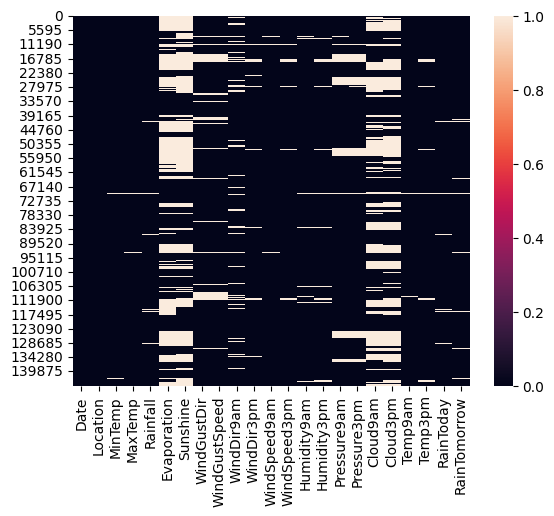

In [5]:
import seaborn as sns
sns.heatmap(data.isna())

In [6]:
(data.isna().sum()/data.shape[0]).sort_values(ascending=True)

Date             0.000000
Location         0.000000
MaxTemp          0.008669
MinTemp          0.010209
Temp9am          0.012148
WindSpeed9am     0.012148
Humidity9am      0.018246
WindSpeed3pm     0.021050
Rainfall         0.022419
RainToday        0.022419
RainTomorrow     0.022460
Temp3pm          0.024811
WindDir3pm       0.029066
Humidity3pm      0.030984
WindGustSpeed    0.070555
WindGustDir      0.070989
WindDir9am       0.072639
Pressure3pm      0.103314
Pressure9am      0.103568
Cloud9am         0.384216
Cloud3pm         0.408071
Evaporation      0.431665
Sunshine         0.480098
dtype: float64

In [7]:
data['Date'] = pd.to_datetime(data['Date'])
num_cols = data.select_dtypes(include='float').columns
cat_cols = data.select_dtypes(include='object').columns

# Imputation simple
data[num_cols] = data[num_cols].fillna(data[num_cols].median())
data[cat_cols] = data[cat_cols].fillna(data[cat_cols].mode().iloc[0])


In [8]:
(data.isna().sum()/data.shape[0]).sort_values(ascending=True)

Date             0.0
Temp3pm          0.0
Temp9am          0.0
Cloud3pm         0.0
Cloud9am         0.0
Pressure3pm      0.0
Pressure9am      0.0
Humidity3pm      0.0
Humidity9am      0.0
WindSpeed3pm     0.0
RainToday        0.0
WindSpeed9am     0.0
WindDir9am       0.0
WindGustSpeed    0.0
WindGustDir      0.0
Sunshine         0.0
Evaporation      0.0
Rainfall         0.0
MaxTemp          0.0
MinTemp          0.0
Location         0.0
WindDir3pm       0.0
RainTomorrow     0.0
dtype: float64

In [9]:
cols_to_drop = ['Evaporation', 'Sunshine', 'Cloud9am', 'Cloud3pm']
data = data.drop(columns=cols_to_drop)


In [10]:
data.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,17.8,29.7,No,No


In [11]:
from sklearn.preprocessing import LabelEncoder
# Encodage de toutes les colonnes catégorielles
for col in data.select_dtypes(include='object').columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))

data = data.rename(columns={"Date": "ds", "Location": "unique_id", "MaxTemp": "y"})


In [ ]:
from neuralforecast.models import NHITS

from neuralforecast import NeuralForecast


#data.head()
# Split data and declare panel dataset
# Trier au cas où
Y_df = data.sort_values(by='ds')

# Récupérer les 12 dernières dates
last_dates = Y_df['ds'].drop_duplicates().sort_values().tail(12)

# Split
Y_train_df = Y_df[~Y_df['ds'].isin(last_dates)]
Y_test_df  = Y_df[Y_df['ds'].isin(last_dates)]
horizon = len(Y_test_df)

model = NeuralForecast(
    models=[NHITS(h=horizon, max_steps=200,input_size=7,enable_progress_bar=False)],
    freq='D'
)

model.fit(data)
# val = model.cross_validation(
#     models=model,
#     df=model,
#     h=12,   # horizon d’évaluation
#     step_size=12
# )
cv_df = model.cross_validation(
    df = data,         # ton DataFrame
    n_windows = 3,     # nombre de fenêtres, par exemple 3
    step_size = 12,     # h = horizon de prédiction
    refit = 1          # (optionnel) si tu veux retrainer pour chaque fenêtre
)





Seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 2.9 M  | train
-------------------------------------------------------
2.9 M     Trainable params
0         Non-trainable params
2.9 M     Total params
11.641    Total estimated model params size (MB)
34        Modules in train mode
0         Modules in eval mode


In [ ]:
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import rmse, mae, mape  # selon ce que tu veux

# Si cv_df contient aussi la colonne 'cutoff', on la retire pour evaluate
eval_df = evaluate(cv_df.drop(columns=['cutoff']), metrics=[rmse, mae, mape])
print(eval_df)




     unique_id metric     NHITS
0            0   rmse  2.915223
1            1   rmse  3.081514
2            2   rmse  2.664799
3            3   rmse  4.103031
4            4   rmse  2.263521
..         ...    ...       ...
142         44   mape  0.167989
143         45   mape  0.099993
144         46   mape  0.127303
145         47   mape  0.079539
146         48   mape  0.111058

[147 rows x 3 columns]


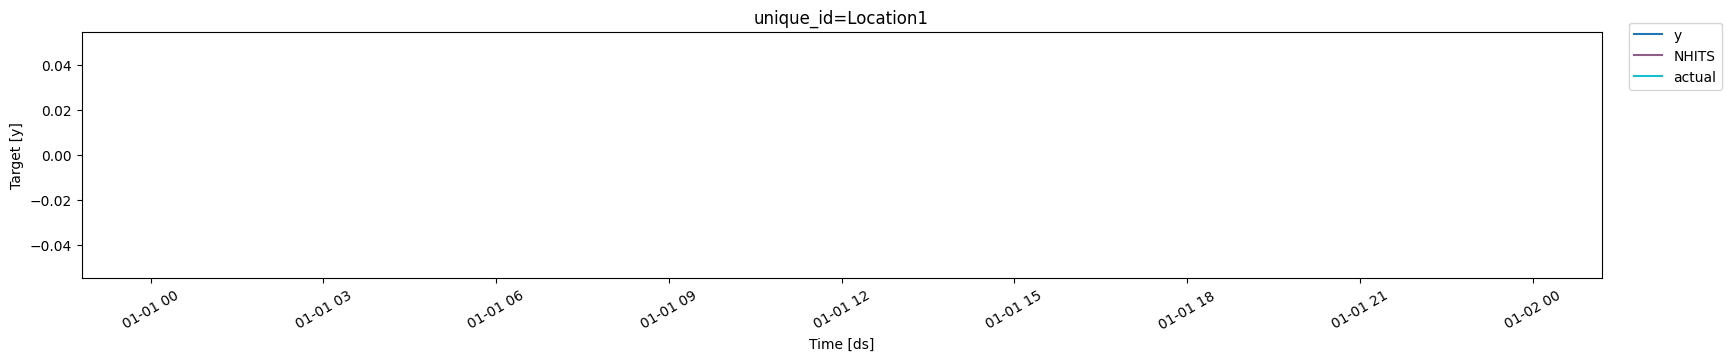

In [ ]:
from utilsforecast.plotting import plot_series

# renommer colonne y → actual
cv_df.rename(columns={'y':'actual'}, inplace=True)

# Puis tracer pour une série donnée
plot_series(data, cv_df.drop(columns='cutoff'), ids=['Location1'])


In [ ]:
data.dtypes


ds               datetime64[ns]
unique_id                 int64
MinTemp                 float64
y                       float64
Rainfall                float64
WindGustDir               int64
WindGustSpeed           float64
WindDir9am                int64
WindDir3pm                int64
WindSpeed9am            float64
WindSpeed3pm            float64
Humidity9am             float64
Humidity3pm             float64
Pressure9am             float64
Pressure3pm             float64
Temp9am                 float64
Temp3pm                 float64
RainToday                 int64
RainTomorrow              int64
dtype: object

In [ ]:
for col in data.columns:
    if data[col].dtype == 'object':
        print(col, data[col].unique()[:10])


In [ ]:
(data.isna().sum()/data.shape[0]).sort_values(ascending=True)

ds               0.0
Temp3pm          0.0
Temp9am          0.0
Pressure3pm      0.0
Pressure9am      0.0
Humidity3pm      0.0
Humidity9am      0.0
WindSpeed3pm     0.0
RainToday        0.0
WindSpeed9am     0.0
WindDir9am       0.0
WindGustSpeed    0.0
WindGustDir      0.0
Rainfall         0.0
y                0.0
MinTemp          0.0
unique_id        0.0
WindDir3pm       0.0
RainTomorrow     0.0
dtype: float64

In [ ]:
data.info

<bound method DataFrame.info of                ds  unique_id  MinTemp     y  Rainfall  WindGustDir  \
0      2008-12-01          2     13.4  22.9       0.6           13   
1      2008-12-02          2      7.4  25.1       0.0           14   
2      2008-12-03          2     12.9  25.7       0.0           15   
3      2008-12-04          2      9.2  28.0       0.0            4   
4      2008-12-05          2     17.5  32.3       1.0           13   
...           ...        ...      ...   ...       ...          ...   
145455 2017-06-21         41      2.8  23.4       0.0            0   
145456 2017-06-22         41      3.6  25.3       0.0            6   
145457 2017-06-23         41      5.4  26.9       0.0            3   
145458 2017-06-24         41      7.8  27.0       0.0            9   
145459 2017-06-25         41     14.9  22.6       0.0           13   

        WindGustSpeed  WindDir9am  WindDir3pm  WindSpeed9am  WindSpeed3pm  \
0                44.0          13          14     

,ds,unique_id,MinTemp,y,Rainfall,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,2,13.4,22.9,0.6,13,44.0,13,14,20.0,24.0,71.0,22.0,1007.7,1007.1,16.9,21.8,0,0
1,2008-12-02,2,7.4,25.1,0.0,14,44.0,6,15,4.0,22.0,44.0,25.0,1010.6,1007.8,17.2,24.3,0,0
2,2008-12-03,2,12.9,25.7,0.0,15,46.0,13,15,19.0,26.0,38.0,30.0,1007.6,1008.7,21.0,23.2,0,0
3,2008-12-04,2,9.2,28.0,0.0,4,24.0,9,0,11.0,9.0,45.0,16.0,1017.6,1012.8,18.1,26.5,0,0
4,2008-12-05,2,17.5,32.3,1.0,13,41.0,1,7,7.0,20.0,82.0,33.0,1010.8,1006.0,17.8,29.7,0,0


In [ ]:
forecast_df = model.predict()


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

In [ ]:
forecast_df.head()

,unique_id,ds,NHITS
0,0,2017-06-19,17.550074
1,0,2017-06-20,17.523592
2,0,2017-06-21,17.465021
3,0,2017-06-22,17.469650
4,0,2017-06-23,17.389339


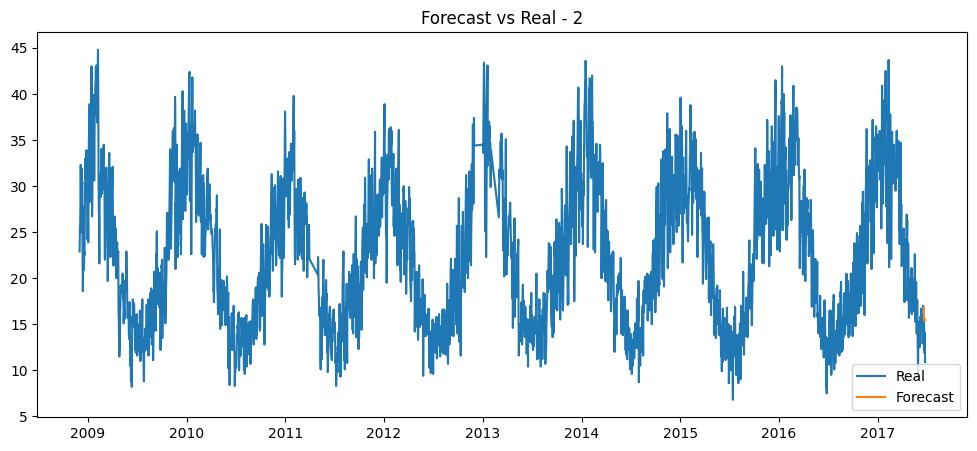

In [ ]:
import matplotlib.pyplot as plt

city = data['unique_id'].unique()[0]  # la première ville

df_city = data[data['unique_id'] == city]
fc_city = forecast_df[forecast_df['unique_id'] == city]

plt.figure(figsize=(12,5))
plt.plot(df_city['ds'], df_city['y'], label='Real')
plt.plot(fc_city['ds'], fc_city['NHITS'], label='Forecast')
plt.legend()
plt.title(f'Forecast vs Real - {city}')
plt.show()


In [ ]:
#model.plot()


AttributeError: 'NeuralForecast' object has no attribute 'plot'

In [ ]:
forecast_city = model.predict().query("unique_id == 3") # Ex: Location ID 3
print(forecast_city)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

    unique_id         ds      NHITS
21          3 2017-06-19  20.709345
22          3 2017-06-20  20.928837
23          3 2017-06-21  21.035778
24          3 2017-06-22  21.057005
25          3 2017-06-23  21.017906
26          3 2017-06-24  20.995258
27          3 2017-06-25  21.014561
